# Metropolis MCMC — Modelo Lineal 2D

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Generar datos lineales y guardar .dat

In [46]:
# Parámetros verdaderos
TRUE_M = 2.5
TRUE_B = -1.0
SIGMA  = 0.8   # ruido conocido

rng = np.random.default_rng(42)
x   = np.linspace(0, 10, 50)
y   = TRUE_M * x + TRUE_B + rng.normal(0, SIGMA, size=len(x))
y_err = np.full_like(y, rng.normal(0, SIGMA, size=len(x)))

np.savetxt('datos_lineales.dat', np.column_stack([x, y, y_err]),
           header='x  y  y_err', comments='# ')
print(f'Datos guardados: pendiente={TRUE_M}, intercepto={TRUE_B}')

Datos guardados: pendiente=2.5, intercepto=-1.0


## 2. Cargar .dat y definir log-posterior

In [47]:
data = np.loadtxt('datos_lineales.dat', comments='#')
x_obs, y_obs, y_err_obs = data[:, 0], data[:, 1], data[:, 2]

def log_posterior(theta, data):
    """Log-posterior: prior plano + log-likelihood Gaussiana."""
    m, b = theta
    x, y, y_err = data[:, 0], data[:, 1], data[:, 2]
    y_pred = m * x + b
    return -0.5 * np.sum(((y - y_pred) / y_err) ** 2)

## 3. Muestreador Metropolis

In [67]:
def metropolis(log_posterior, data, theta_init, proposal_std, n_samples, rng):
    dim    = len(theta_init)
    chain  = np.empty((n_samples, dim))
    chain[0] = theta_init
    log_p  = log_posterior(chain[0], data)
    n_acc  = 0
    for i in range(1, n_samples):
        proposal   = chain[i-1] + rng.normal(0, proposal_std, size=dim)
        log_p_prop = log_posterior(proposal, data)
        if np.log(rng.uniform()) < log_p_prop - log_p:
            chain[i], log_p, n_acc = proposal, log_p_prop, n_acc + 1
        else:
            chain[i] = chain[i-1]
    return chain, n_acc / (n_samples - 1)

chain, acc = metropolis(
    log_posterior, data,
    theta_init   = np.array([0.0, 0.0]),
    proposal_std = np.array([0.001, 0.04]),
    n_samples    = 20_000,
    rng          = rng,
)

BURNIN  = 2_000
samples = chain[BURNIN:]
print(f'Tasa de aceptación: {acc:.3f}')
print(f'Media posterior — m: {samples[:,0].mean():.4f}  b: {samples[:,1].mean():.4f}')
print(f'Valores verdaderos — m: {TRUE_M}  b: {TRUE_B}')

Tasa de aceptación: 0.320
Media posterior — m: 1.9588  b: 2.4258
Valores verdaderos — m: 2.5  b: -1.0


## 4. Plots

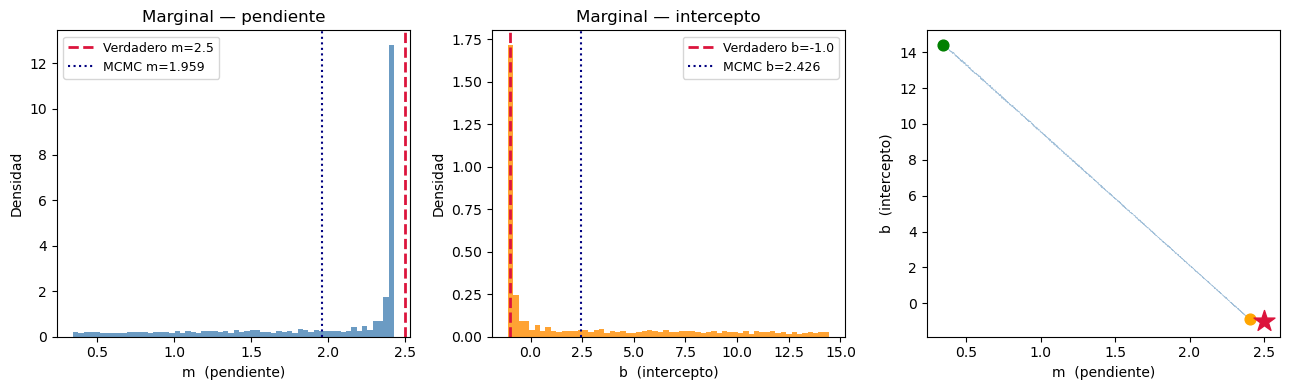

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Histograma marginal — pendiente m
axes[0].hist(samples[:, 0], bins=60, density=True, color='steelblue', alpha=0.8)
axes[0].axvline(TRUE_M, color='crimson', lw=2, linestyle='--', label=f'Verdadero m={TRUE_M}')
axes[0].axvline(samples[:, 0].mean(), color='navy', lw=1.5, linestyle=':', label=f'MCMC m={samples[:,0].mean():.3f}')
axes[0].set_xlabel('m  (pendiente)')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Marginal — pendiente')
axes[0].legend(fontsize=9)

# Histograma marginal — intercepto b
axes[1].hist(samples[:, 1], bins=60, density=True, color='darkorange', alpha=0.8)
axes[1].axvline(TRUE_B, color='crimson', lw=2, linestyle='--', label=f'Verdadero b={TRUE_B}')
axes[1].axvline(samples[:, 1].mean(), color='navy', lw=1.5, linestyle=':', label=f'MCMC b={samples[:,1].mean():.3f}')
axes[1].set_xlabel('b  (intercepto)')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Marginal — intercepto')
axes[1].legend(fontsize=9)

# Caminante en el espacio de parámetros
axes[2].plot(samples[:, 0], samples[:, 1],
             lw=0.4, alpha=0.5, color='steelblue', zorder=1)
axes[2].scatter(samples[0, 0], samples[0, 1], color='green',
                s=60, zorder=5, label='Inicio')
axes[2].scatter(samples[-1, 0], samples[-1, 1], color='orange',
                s=60, zorder=5, label='Fin')
axes[2].scatter(TRUE_M, TRUE_B, color='crimson', marker='*',
                s=250, zorder=10, label='Verdadero')
axes[2].set_xlabel('m  (pendiente)')
axes[2].set_ylabel('b  (intercepto)')

plt.tight_layout()
plt.savefig('mcmc_linear_results.png', dpi=130, bbox_inches='tight')
plt.show()

## Probar con Datos Dados

### line-1.dat

In [39]:
data = np.loadtxt('line-1.dat', comments='#')
x_obs, y_obs = data[0, :], data[1, :]

chain, acc = metropolis(
    log_posterior, data,
    theta_init   = np.array([0.0, 0.0]),
    proposal_std = np.array([0.7, 0.95]),
    n_samples    = 20_000,
    rng          = rng,
)

BURNIN  = 2_000
samples = chain[BURNIN:]
print(f'Tasa de aceptación: {acc:.3f}')
print(f'Media posterior — m: {samples[:,0].mean():.4f}  b: {samples[:,1].mean():.4f}')

Tasa de aceptación: 0.244
Media posterior — m: 0.8046  b: 0.4154


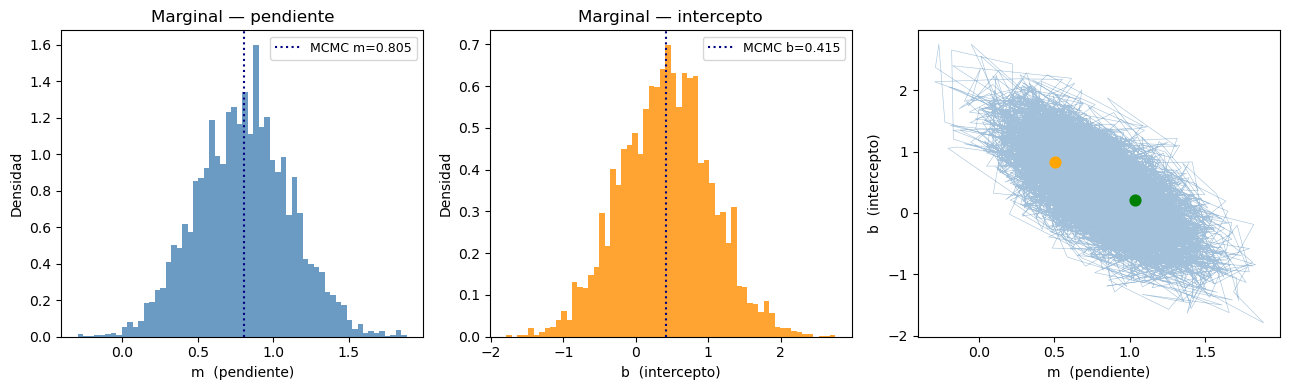

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Histograma marginal — pendiente m
axes[0].hist(samples[:, 0], bins=60, density=True, color='steelblue', alpha=0.8)
axes[0].axvline(samples[:, 0].mean(), color='navy', lw=1.5, linestyle=':', label=f'MCMC m={samples[:,0].mean():.3f}')
axes[0].set_xlabel('m  (pendiente)')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Marginal — pendiente')
axes[0].legend(fontsize=9)

# Histograma marginal — intercepto b
axes[1].hist(samples[:, 1], bins=60, density=True, color='darkorange', alpha=0.8)
axes[1].axvline(samples[:, 1].mean(), color='navy', lw=1.5, linestyle=':', label=f'MCMC b={samples[:,1].mean():.3f}')
axes[1].set_xlabel('b  (intercepto)')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Marginal — intercepto')
axes[1].legend(fontsize=9)

# Caminante en el espacio de parámetros
axes[2].plot(samples[:, 0], samples[:, 1],
             lw=0.4, alpha=0.5, color='steelblue', zorder=1)
axes[2].scatter(samples[0, 0], samples[0, 1], color='green',
                s=60, zorder=5, label='Inicio')
axes[2].scatter(samples[-1, 0], samples[-1, 1], color='orange',
                s=60, zorder=5, label='Fin')
axes[2].set_xlabel('m  (pendiente)')
axes[2].set_ylabel('b  (intercepto)')

plt.tight_layout()
plt.savefig('mcmc_linear_results_line-1.png', dpi=130, bbox_inches='tight')
plt.show()

### line-2.dat

In [41]:
data = np.loadtxt('line-2.dat', comments='#')
x_obs, y_obs = data[0, :], data[1, :]

chain, acc = metropolis(
    log_posterior, data,
    theta_init   = np.array([0.0, 0.0]),
    proposal_std = np.array([0.4, 0.65]),
    n_samples    = 20_000,
    rng          = rng,
)

BURNIN  = 2_000
samples = chain[BURNIN:]
print(f'Tasa de aceptación: {acc:.3f}')
print(f'Media posterior — m: {samples[:,0].mean():.4f}  b: {samples[:,1].mean():.4f}')

Tasa de aceptación: 0.251
Media posterior — m: 0.3665  b: 0.5513


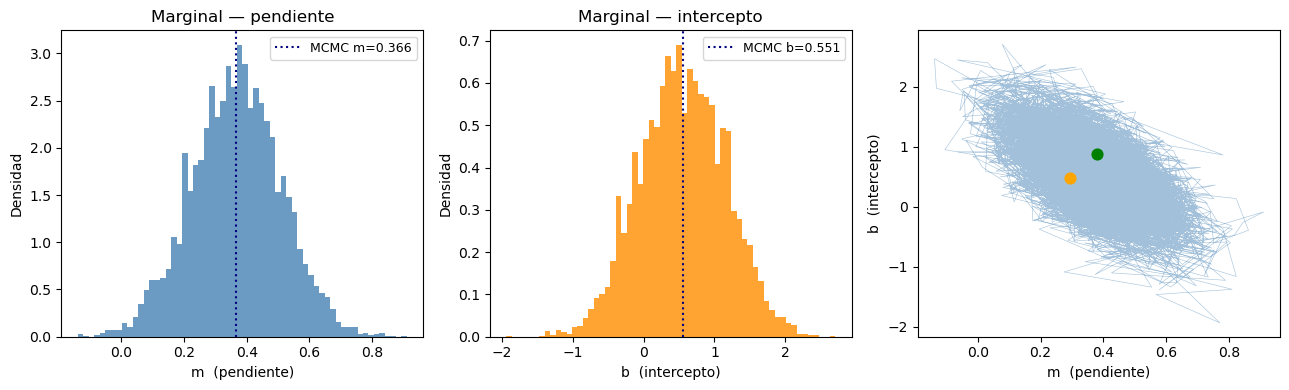

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Histograma marginal — pendiente m
axes[0].hist(samples[:, 0], bins=60, density=True, color='steelblue', alpha=0.8)
axes[0].axvline(samples[:, 0].mean(), color='navy', lw=1.5, linestyle=':', label=f'MCMC m={samples[:,0].mean():.3f}')
axes[0].set_xlabel('m  (pendiente)')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Marginal — pendiente')
axes[0].legend(fontsize=9)

# Histograma marginal — intercepto b
axes[1].hist(samples[:, 1], bins=60, density=True, color='darkorange', alpha=0.8)
axes[1].axvline(samples[:, 1].mean(), color='navy', lw=1.5, linestyle=':', label=f'MCMC b={samples[:,1].mean():.3f}')
axes[1].set_xlabel('b  (intercepto)')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Marginal — intercepto')
axes[1].legend(fontsize=9)

# Caminante en el espacio de parámetros
axes[2].plot(samples[:, 0], samples[:, 1],
             lw=0.4, alpha=0.5, color='steelblue', zorder=1)
axes[2].scatter(samples[0, 0], samples[0, 1], color='green',
                s=60, zorder=5, label='Inicio')
axes[2].scatter(samples[-1, 0], samples[-1, 1], color='orange',
                s=60, zorder=5, label='Fin')
axes[2].set_xlabel('m  (pendiente)')
axes[2].set_ylabel('b  (intercepto)')

plt.tight_layout()
plt.savefig('mcmc_linear_results_line-2.png', dpi=130, bbox_inches='tight')
plt.show()